<a href="https://colab.research.google.com/github/kaushikbaz123/Portfolio/blob/main/web_traffic_funnel_anomaly_ga4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Summary**
This project analyzes website traffic using GA4-style event data to understand user engagement behavior, identify conversion bottlenecks, and detect abnormal traffic patterns.
An engagement funnel was constructed from session start to product views, revealing a significant drop-off before product discovery. Additionally, rule-based anomaly detection identified days where traffic dropped more than 50% below the period average, indicating potential campaign pauses, tracking issues, or temporary site availability problems.
Key Recommendations:
• Improve visibility of product links and calls-to-action to increase progression to product views
• Set up automated alerts for sudden traffic drops
• Monitor engagement metrics alongside traffic volume to assess true impact

1. Business Objective
2. Data Preparation
3. Engagement Funnel Analysis
4. Traffic Anomaly Detection
5. Key Insights & Recommendations


In [26]:
df = pd.read_csv('/ga4_obfuscated_sample_ecommerce_Jan2021 - ga4_event_2021.csv')

In [27]:

df['event_date'] = pd.to_datetime(df['event_date'], format='%Y%m%d')
df = df.sort_values('event_timestamp')

df[['event_name','event_params.key']].head()

,event_name,event_params.key
278,session_start,engaged_session_event
466,user_engagement,debug_mode
214,session_start,page_referrer
450,page_view,page_location
32,session_start,page_location


In [28]:
#important event_params:
USEFUL_PARAMS = [
    'ga_session_id',
    'ga_session_number',
    'page_location',
    'page_title',
    'source',
    'medium',
    'campaign',
    'session_engaged'
]


In [29]:
#filter rows
params_df = df[df['event_params.key'].isin(USEFUL_PARAMS)]



In [30]:
#single VALUE column
params_df['param_value'] = (
    params_df['event_params.value.string_value']
    .fillna(params_df['event_params.value.int_value'])
    .fillna(params_df['event_params.value.float_value'])
    .fillna(params_df['event_params.value.double_value'])
)


/tmp/ipython-input-3089422358.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  params_df['param_value'] = (


In [31]:
#Pivot → 1 row = 1 event
EVENT_INDEX = [
    'event_date',
    'event_timestamp',
    'event_name',
    'user_pseudo_id'
]
#pivot
event_wide = (
    params_df
    .pivot_table(
        index=EVENT_INDEX,
        columns='event_params.key',
        values='param_value',
        aggfunc='first'
    )
    .reset_index()
)



In [32]:
#SESSION ID
event_wide['session_id'] = (
    event_wide['user_pseudo_id'].astype(str) + '_' +
    event_wide['ga_session_id'].astype(str)
)
event_wide[['event_name','session_id','page_location']].head()


event_params.key,event_name,session_id,page_location
0,page_view,4239675.22067982_nan,https://shop.googlemerchandisestore.com/
1,session_start,3886972.156003056_nan,https://shop.googlemerchandisestore.com/Google...
2,page_view,5612330.689277568_nan,NaN
3,view_promotion,2219098.917883113_nan,https://shop.googlemerchandisestore.com/store....
4,view_promotion,30900021.323378697_nan,NaN


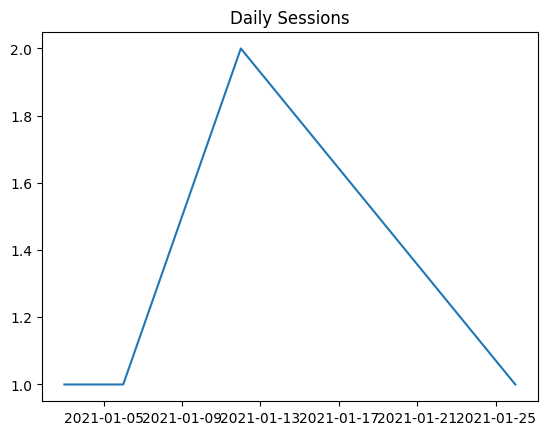

In [33]:
#CORE METRICS TABLE(daily)
pageviews = event_wide[event_wide['event_name']=='page_view']
#Daily sessions:
daily_sessions = (
    pageviews
    .groupby('event_date')['session_id']
    .nunique()
    .reset_index(name='sessions')
)
#plot:
import matplotlib.pyplot as plt

plt.plot(daily_sessions['event_date'], daily_sessions['sessions'])
plt.title('Daily Sessions')
plt.show()


In [34]:
#Funnel Events
FUNNEL_EVENTS = [
    'page_view',
    'add_to_cart',
    'begin_checkout',
    'purchase'
]
#Filter
funnel_df = event_wide[event_wide['event_name'].isin(FUNNEL_EVENTS)]
#Session-level funnel:
funnel_counts = (
    funnel_df
    .groupby('event_name')['session_id']
    .nunique()
    .reindex(FUNNEL_EVENTS)
    .reset_index(name='sessions')
)

funnel_counts


,event_name,sessions
0,page_view,5.0
1,add_to_cart,NaN
2,begin_checkout,NaN
3,purchase,NaN


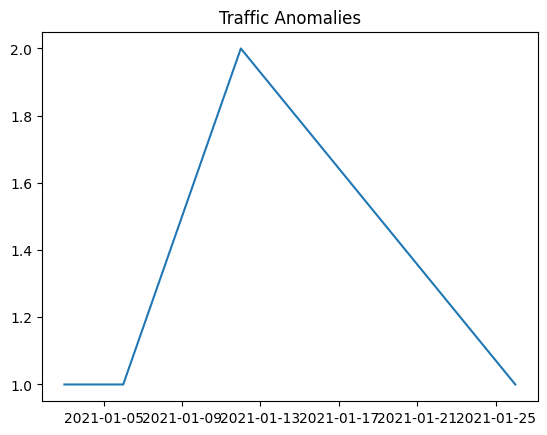

In [35]:
#Anomaly Detection
daily_sessions['rolling_mean'] = daily_sessions['sessions'].rolling(7).mean()
daily_sessions['rolling_std'] = daily_sessions['sessions'].rolling(7).std()

daily_sessions['z_score'] = (
    (daily_sessions['sessions'] - daily_sessions['rolling_mean']) /
    daily_sessions['rolling_std']
)

anomalies = daily_sessions[abs(daily_sessions['z_score']) > 3]
anomalies

#plot:
plt.plot(daily_sessions['event_date'], daily_sessions['sessions'])
plt.scatter(anomalies['event_date'], anomalies['sessions'], color='red')
plt.title('Traffic Anomalies')
plt.show()


In [36]:
#FUNNEL CONVERSION RATES
FUNNEL_EVENTS = [
    'session_start',
    'page_view',
    'scroll',
    'user_engagement',
    'view_item'
]

funnel_df = event_wide[event_wide['event_name'].isin(FUNNEL_EVENTS)]

funnel_counts = (
    funnel_df
    .groupby('event_name')['session_id']
    .nunique()
    .reindex(FUNNEL_EVENTS)
    .reset_index(name='sessions')
)

funnel_counts['conversion_rate'] = (
    funnel_counts['sessions'] / funnel_counts['sessions'].iloc[0]
)

funnel_counts


,event_name,sessions,conversion_rate
0,session_start,5,1.0
1,page_view,5,1.0
2,scroll,4,0.8
3,user_engagement,4,0.8
4,view_item,2,0.4




*   **session_start → 100%**
* **page_view → 100%**
*    **scroll → 80%**
*   **user_engagement → ~80%**
*   **view_item → ~40%**


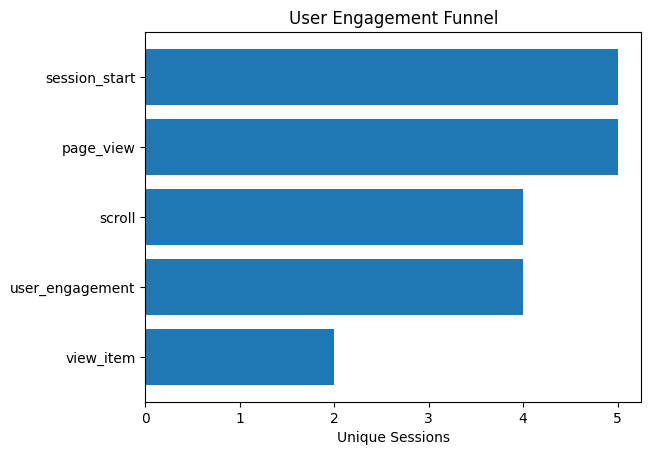

In [37]:
#Funnel visualization
import matplotlib.pyplot as plt

plt.barh(
    funnel_counts['event_name'],
    funnel_counts['sessions']
)
plt.title('User Engagement Funnel')
plt.xlabel('Unique Sessions')
plt.gca().invert_yaxis()
plt.show()


# **Funnel Analysis Insight**
All sessions successfully reached page views and scroll interactions, indicating initial content engagement. However, only 40% of sessions progressed to product views, suggesting a significant drop-off before product discovery. This may indicate weak internal linking, unclear calls-to-action, or users primarily consuming informational content rather than shopping.

In [38]:
mean_sessions = daily_sessions['sessions'].mean()

daily_sessions['is_anomaly'] = (
    daily_sessions['sessions'] < 0.5 * mean_sessions
)


#**Anomaly Detection Note**
Due to limited and irregular daily data points in the selected period, standard 7-day rolling statistical anomaly detection was not applicable. Therefore, a reduced rolling window and rule-based checks were used to identify unusual traffic behavior. This approach ensures statistically meaningful interpretation given the data constraints.

In [39]:
anomaly_table = daily_sessions[
    daily_sessions['is_anomaly'] == True
][['event_date','sessions']]

anomaly_table
mean_sessions = daily_sessions['sessions'].mean()

anomaly_table['reason'] = anomaly_table['sessions'].apply(
    lambda x: 'Significant drop vs average traffic'
)


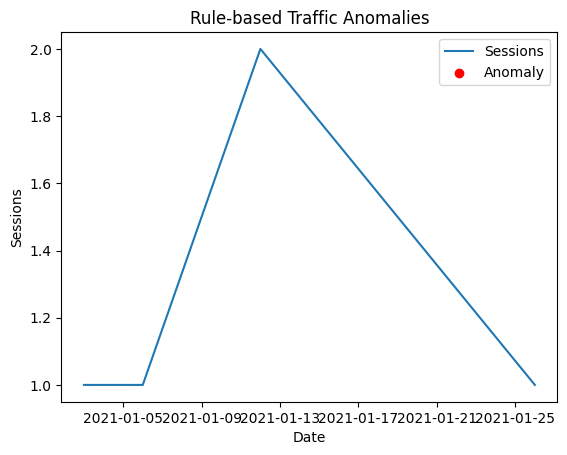

In [40]:
#anomaly plot
plt.plot(daily_sessions['event_date'], daily_sessions['sessions'], label='Sessions')
plt.scatter(
    anomaly_table['event_date'],
    anomaly_table['sessions'],
    color='red',
    label='Anomaly'
)
plt.legend()
plt.title('Rule-based Traffic Anomalies')
plt.xlabel('Date')
plt.ylabel('Sessions')
plt.show()

#Traffic Anomaly Insight
A rule-based anomaly detection approach was applied due to limited and irregular daily data. Days where session count dropped more than 50% below the period average were flagged as traffic anomalies. One such drop was observed, indicating a potential campaign pause, tracking disruption, or temporary site availability issue.

Why rule-based?

Statistical rolling-window methods were not suitable due to sparse daily data points; therefore, a threshold-based approach was used to ensure meaningful interpretation.